# IBM Employee Attrition: Exploratory Data Analysis

## Project Overview

This notebook explores the IBM HR Employee Attrition dataset to understand its structure, data quality, and available features. The main objective is to identify the target variable, examine numerical and categorical columns, investigate missing or duplicate data, and detect any suspicious, constant, or potentially unhelpful features.

The findings from this exploratory analysis will guide later decisions about data preparation, feature selection, and classification modelling. No features will be removed or transformed without first examining and justifying the decision.

## Data Import

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("Data.csv")

## Data inspection

In [ ]:
data.head()

In [ ]:
data.shape

In [ ]:
data.describe().T

In [ ]:
data.describe(include='object').T

In [ ]:
data.duplicated().sum()

In [ ]:
data.isnull().sum().sum()

In [ ]:
cat_col = data.select_dtypes(include="object").columns.tolist()
num_col = data.select_dtypes(include="number").columns.tolist()

In [ ]:
print(f"There are {len(cat_col)} string/categorical columns")
print(f"There are {len(num_col)} numerical columns")

### Data Inspection Summary

The dataset contains 1,470 records and 35 columns, with no missing values or duplicate rows. The numerical and categorical summaries show that most features have valid ranges and manageable category counts.

The target variable, `Attrition`, contains two classes and is imbalanced, with substantially fewer employees leaving than staying. Gender shows a reasonably balanced distribution, while some columns appear constant or potentially uninformative and will require further investigation before modelling.

Overall, the dataset is structurally clean, but additional exploration is still needed to understand feature relevance and relationships with employee attrition.

## Exploratory Data Visualization

This section uses visualizations to better understand the dataset, examine feature distributions, and explore how numerical and categorical features relate to the target variable, `Attrition`. The results will help identify potentially useful, weak, suspicious, or imbalanced features before data preparation and modelling.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
ax = sns.countplot(data=data, x='Attrition',hue='Attrition', palette="Set2", legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Attrition Class Distribution')
plt.xlabel('Attrition')
plt.ylabel('Employee Count')
plt.show()

The target variable is clearly imbalanced. Out of 1,470 employees, 1,233 employees (approximately 84%) remained with the company, while 237 employees (approximately 16%) left.

This imbalance means that accuracy alone may give a misleading impression of model performance. Later evaluation should therefore also consider metrics that reflect how well the model identifies employees who leave.

In [ ]:
numerical_columns = data.select_dtypes(include="number").columns.tolist()
for column in numerical_columns:
    fig = plt.figure(figsize=(16,10))
    ax0 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,2)

    sns.boxplot(data=data, x='Attrition', y=column, hue='Attrition', palette="Set2", ax=ax0)
    ax0.set_xlabel('Attrition')
    ax0.set_ylabel(column)
    ax0.set_title(f"{column} Distribution by Employee Attrition")

    sns.histplot(data=data, x=column, hue='Attrition', stat="probability", common_norm=False ,bins=6 , ax=ax1)
    ax1.set_title(f'{column} Distribution by Employee Attrition')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Proportion within each attrition class')

    plt.show()



### Numerical Feature Visualization Summary

The visual analysis identified `Age`, `JobLevel`, `JobSatisfaction`, `EnvironmentSatisfaction`, `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, and `YearsWithCurrManager` as promising numerical features because their distributions showed noticeable differences between employees who left and those who stayed.

`DistanceFromHome`, `NumCompaniesWorked`, `StockOptionLevel`, `WorkLifeBalance`, and `RelationshipSatisfaction` showed weaker but potentially useful patterns, so they will be retained for further evaluation.

`DailyRate`, `Education`, `HourlyRate`, `JobInvolvement`, `MonthlyRate`, `PercentSalaryHike`, and `YearsSinceLastPromotion` showed substantial overlap and are currently considered weak features. `PerformanceRating` and `TrainingTimesLastYear` are strong removal candidates because they provided almost no visible separation.

`EmployeeCount` and `StandardHours` are constant columns, while `EmployeeNumber` is only a unique identifier. These features provide no predictive value and will be removed before modelling.

These decisions are based on univariate visualization and will later be confirmed through statistical analysis and validated model performance.

C:\Users\Admin\AppData\Local\Temp\ipykernel_21640\2958346962.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_column = data.select_dtypes(include="object").columns.tolist()


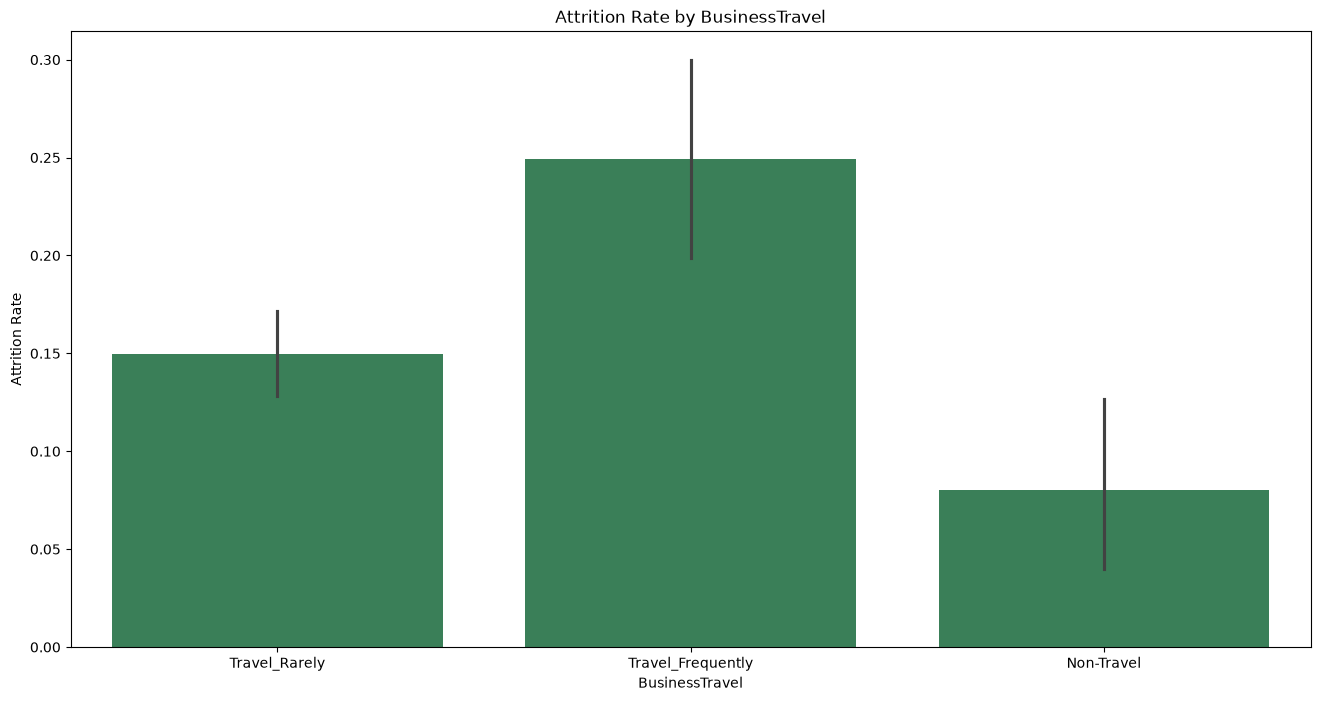

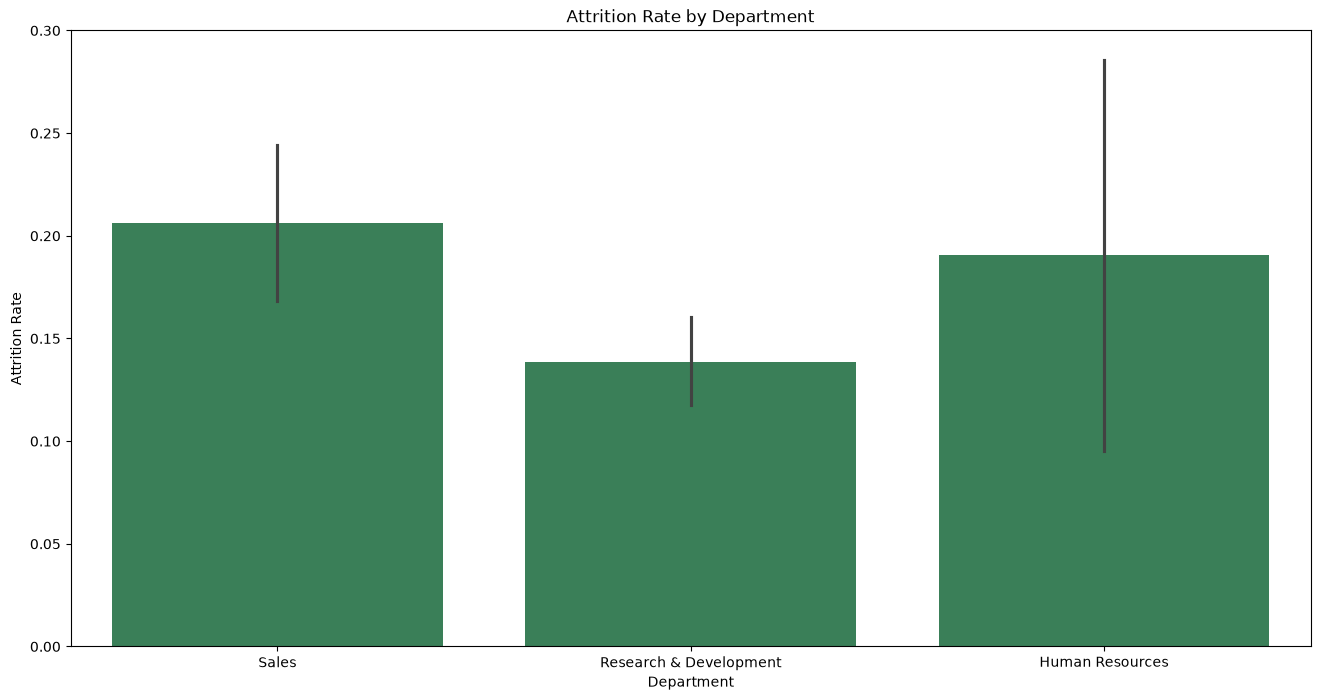

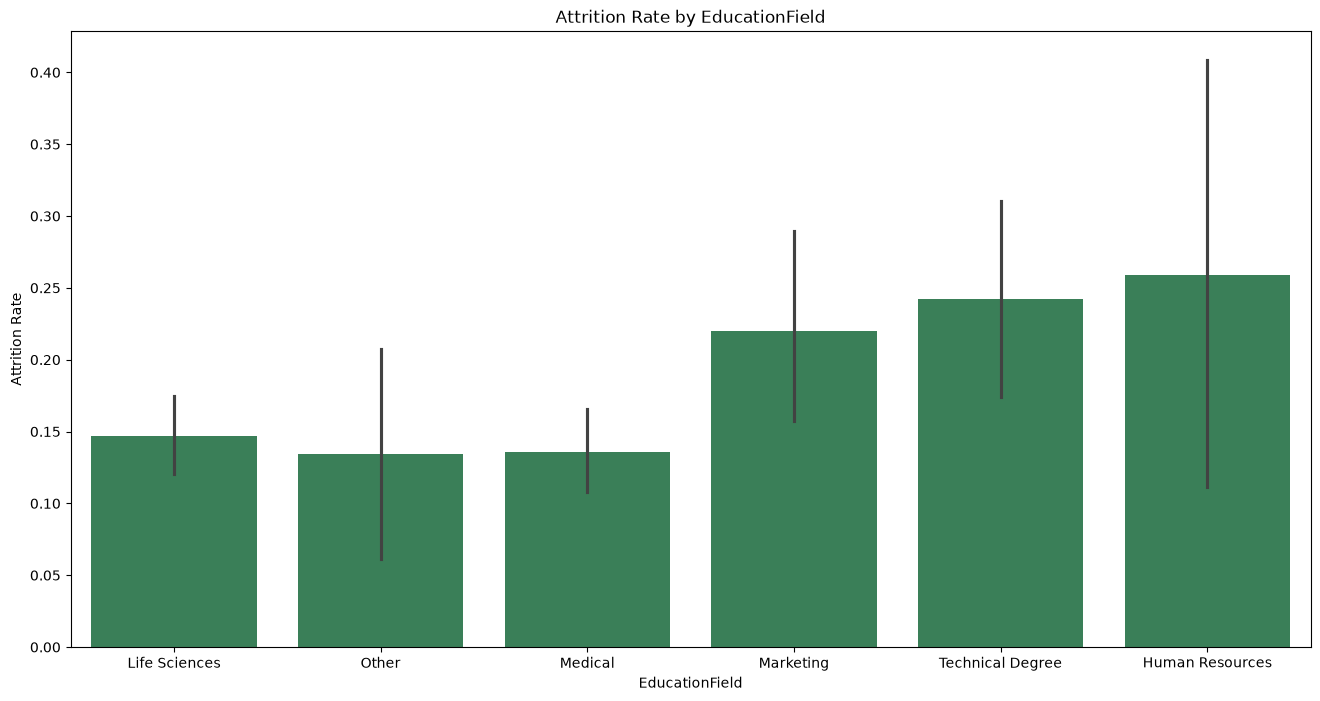

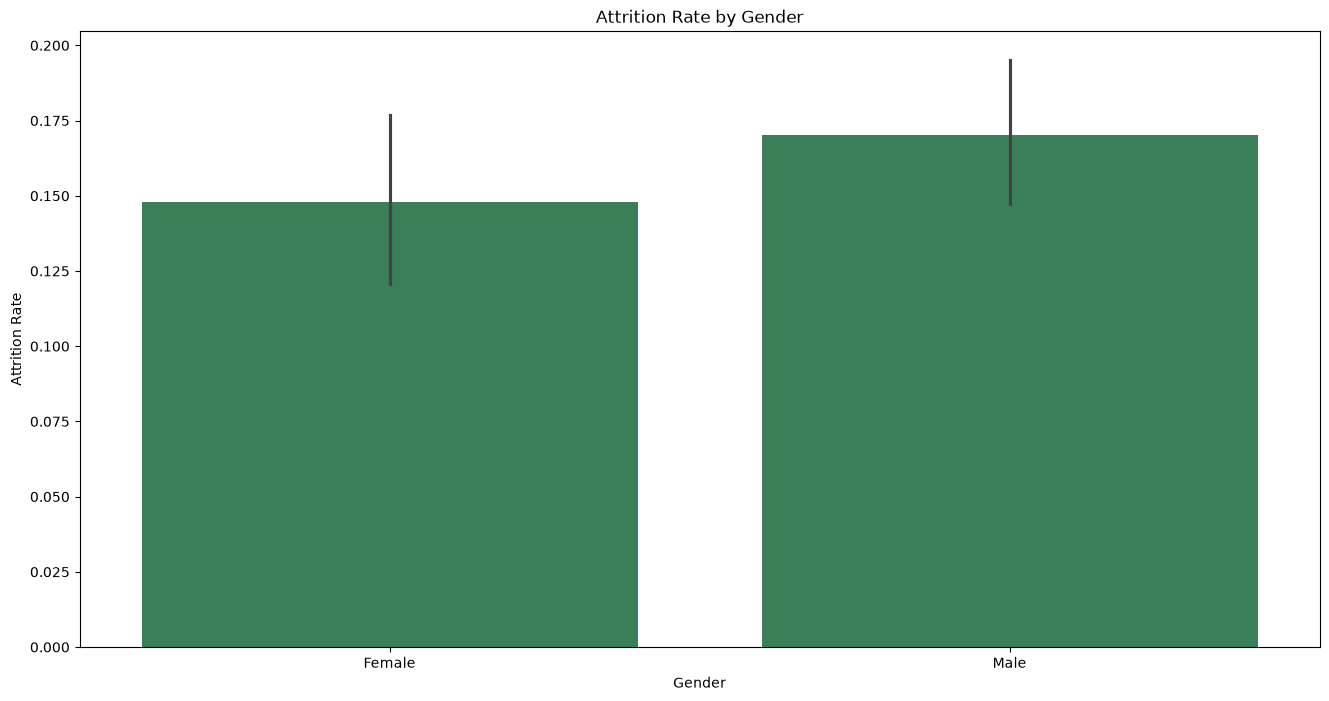

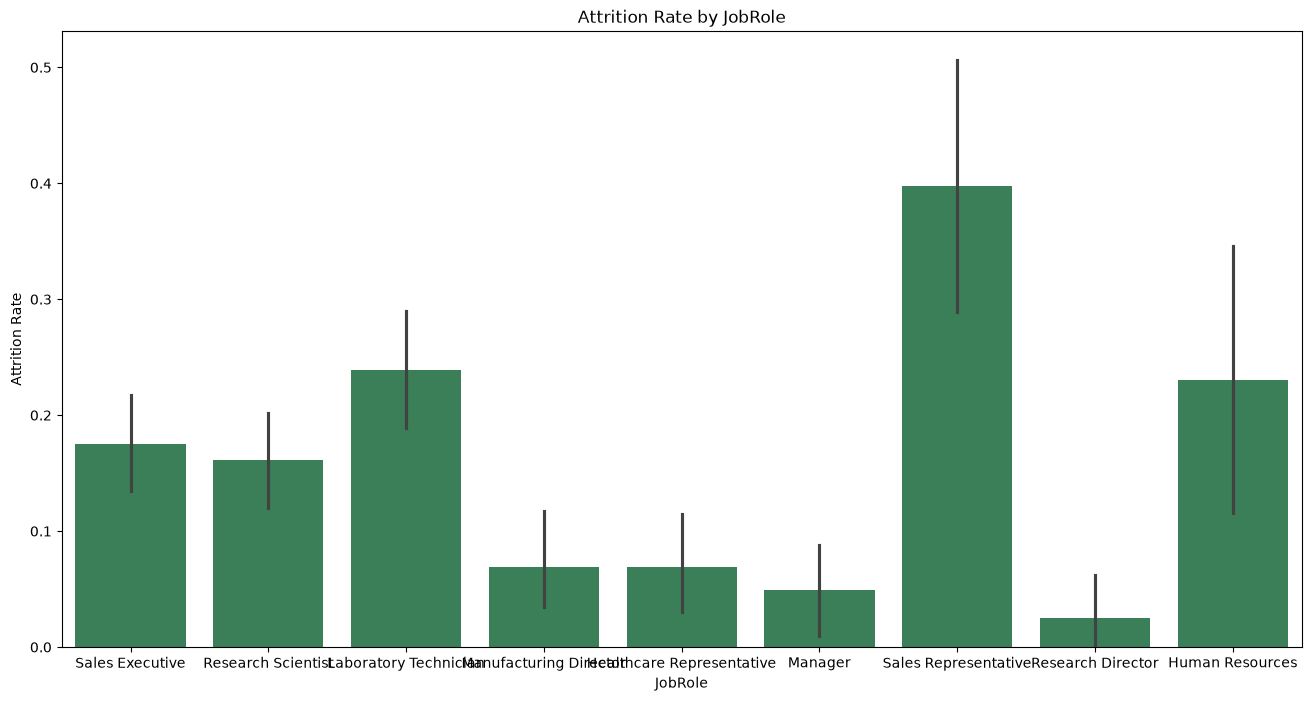

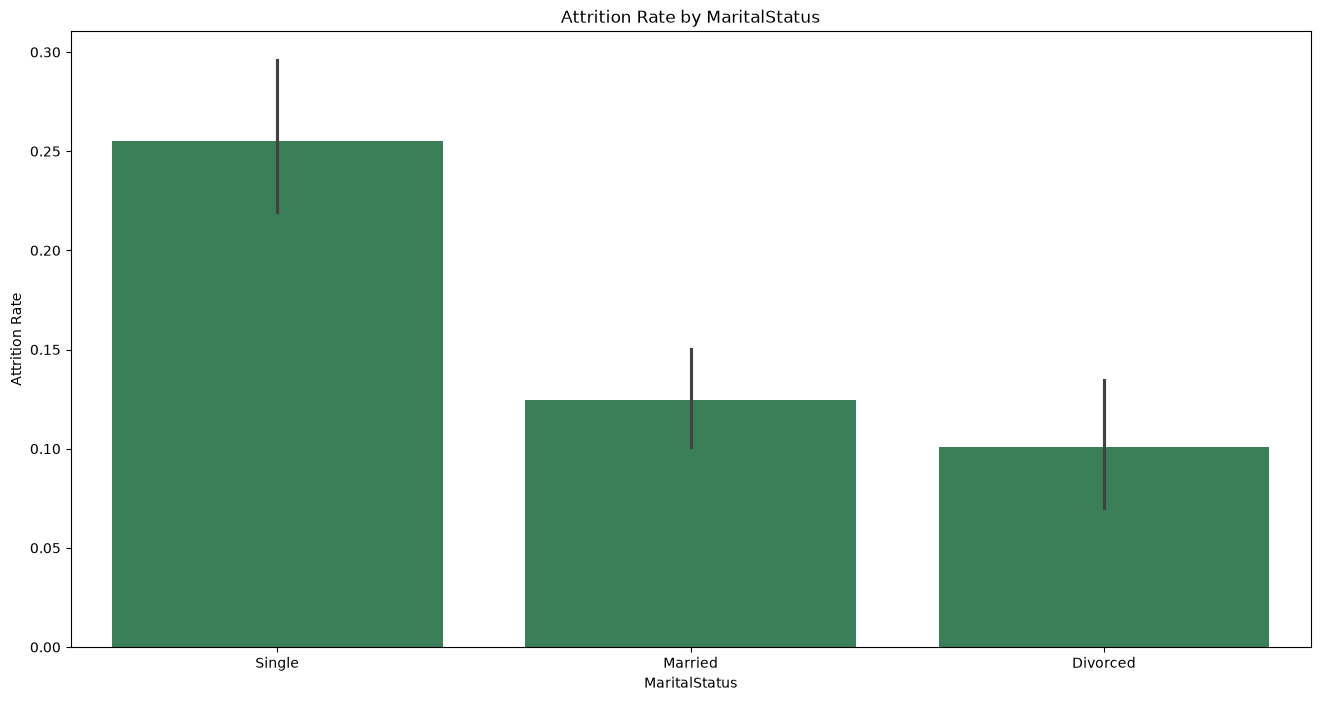

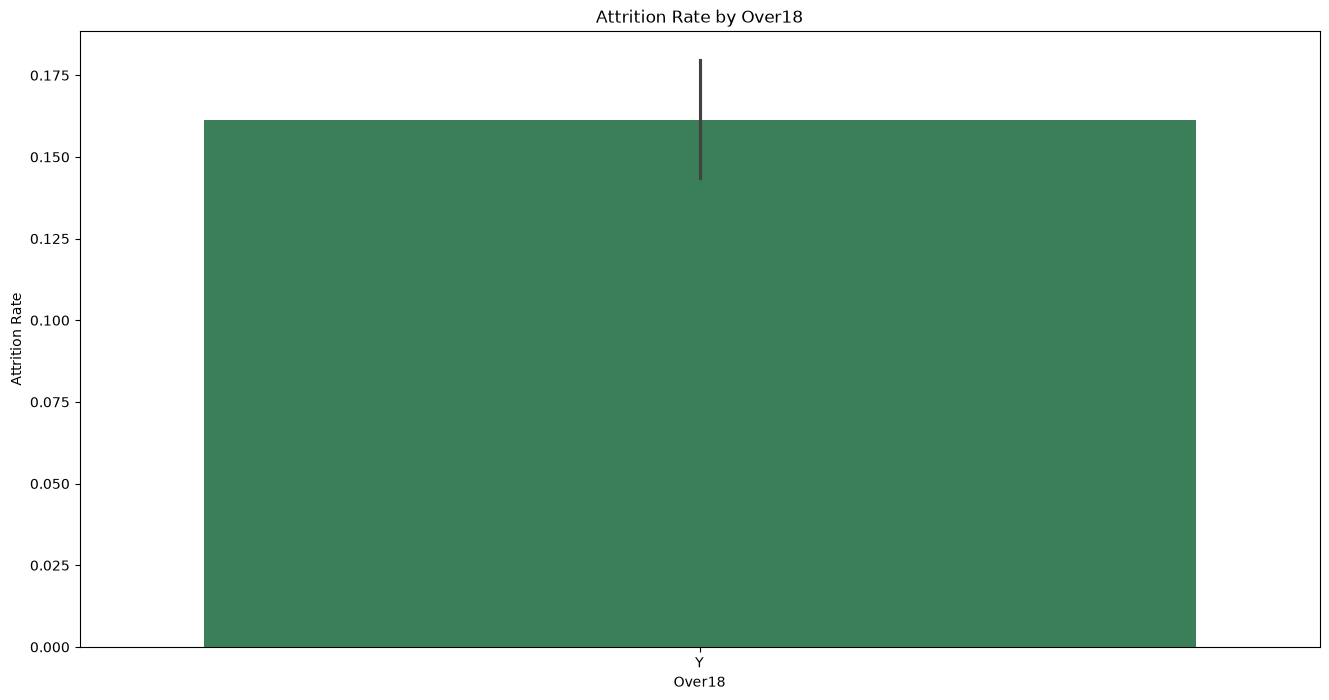

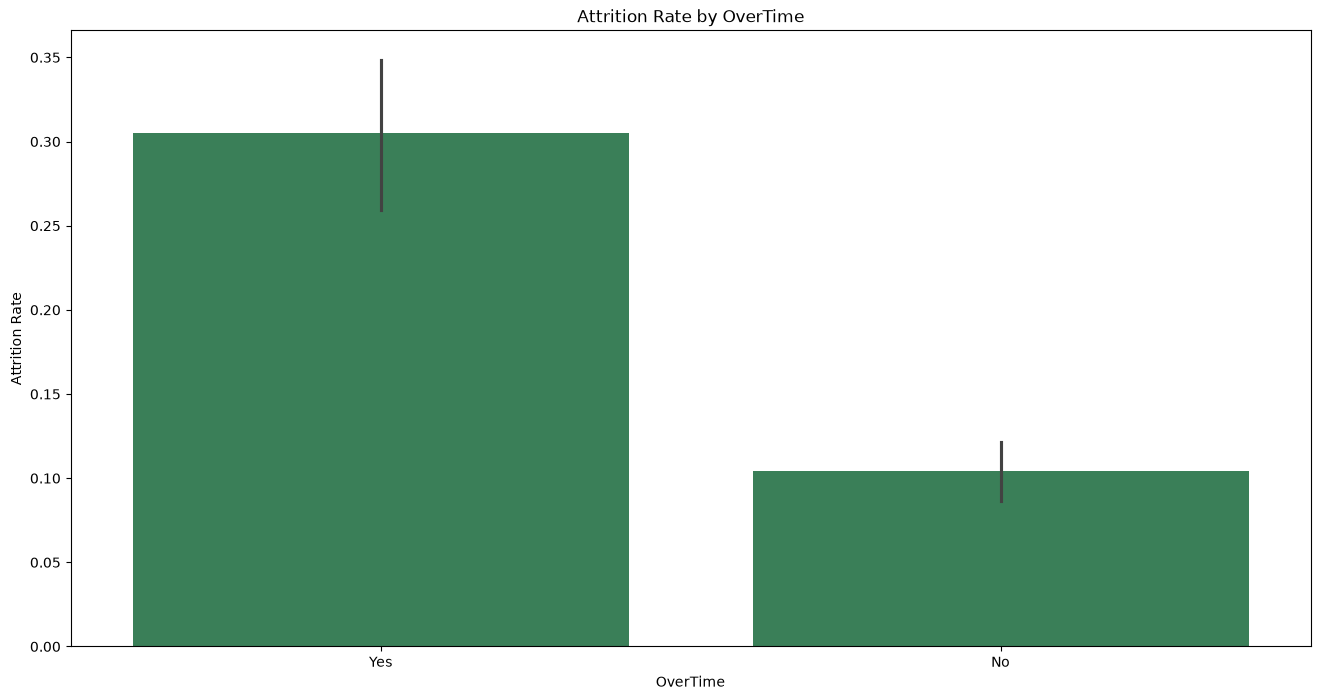

In [ ]:
categorical_column = data.select_dtypes(include="object").columns.tolist()
categorical_column.remove('Attrition')
data['Attrition_Numeric'] = data['Attrition'].map({'No':0, 'Yes':1})


for column in categorical_column:
    plt.figure(figsize=(20,8))
    sns.barplot(data=data, x=column, y='Attrition_Numeric', color="seagreen")
    plt.title(f'Attrition Rate by {column}')
    plt.xlabel(column)
    plt.ylabel("Attrition Rate")
    plt.show()